In [35]:
import heapq
from collections import deque

# --- 1. ENVIRONMENT DESIGN (Categorized Map) ---
edges = [
    # (Node A, Node B, Length, Time, Incidents, Blocked, Type)
    ('Dhanmondi', 'Farmgate', 4, 15, 2, False, 'Primary'),
    ('Dhanmondi', 'Shahbagh', 3, 10, 1, False, 'Primary'),
    ('Dhanmondi', 'Mohammadpur', 2, 10, 5, False, 'Alley'),
    ('Mohammadpur', 'Mirpur', 5, 20, 3, False, 'Primary'),
    ('Shahbagh', 'Farmgate', 3, 12, 2, False, 'Primary'),
    ('Shahbagh', 'Motijheel', 4, 20, 4, True, 'Primary'),   # BLOCKED ROAD
    ('Shahbagh', 'Moghbazar', 2, 10, 3, False, 'Alley'),
    ('Farmgate', 'Banani', 6, 18, 1, False, 'Primary'),
    ('Farmgate', 'Tejgaon', 2, 10, 8, False, 'Alley'),      # HIGH RISK ALLEY
    ('Farmgate', 'Moghbazar', 3, 12, 2, False, 'Primary'),
    ('Mirpur', 'Banani', 7, 25, 2, False, 'Primary'),
    ('Mirpur', 'Mohakhali', 6, 20, 4, False, 'Primary'),
    ('Tejgaon', 'Gulshan', 3, 15, 6, False, 'Alley'),       # HIGH RISK ALLEY
    ('Tejgaon', 'Mohakhali', 2, 8, 3, False, 'Alley'),
    ('Banani', 'Gulshan', 2, 10, 1, False, 'Primary'),
    ('Banani', 'Mohakhali', 2, 8, 1, False, 'Primary'),
    ('Motijheel', 'Gulshan', 8, 30, 3, False, 'Primary'),
    ('Motijheel', 'Rampura', 4, 15, 2, False, 'Primary'),
    ('Moghbazar', 'Rampura', 3, 12, 3, False, 'Alley'),
    ('Mohakhali', 'Badda', 4, 15, 2, False, 'Primary'),
    ('Rampura', 'Badda', 2, 10, 1, False, 'Primary'),
    ('Badda', 'Gulshan', 3, 12, 1, False, 'Primary'),
    ('Motijheel', 'Khilgaon', 2, 10, 1, False, 'Alley'),
    ('Khilgaon', 'Rampura', 3, 15, 2, False, 'Alley')
]

dhaka_map = {}
for u, v, length, time, incidents, blocked, road_type in edges:
    if u not in dhaka_map: dhaka_map[u] = {}
    if v not in dhaka_map: dhaka_map[v] = {}
    data = {'length': length, 'time': time, 'incidents': incidents, 'blocked': blocked, 'type': road_type}
    dhaka_map[u][v] = data
    dhaka_map[v][u] = data

base_heuristics = {
    'Gulshan': 0, 'Banani': 2, 'Badda': 3, 'Tejgaon': 3,
    'Mohakhali': 4, 'Rampura': 5, 'Moghbazar': 6, 'Farmgate': 6,
    'Motijheel': 8, 'Khilgaon': 9, 'Shahbagh': 8, 'Mirpur': 8,
    'Dhanmondi': 10, 'Mohammadpur': 11
}

# --- 2. MULTI-OBJECTIVE COST & HEURISTIC ---
def get_edge_cost(edge_data, profile):
    if edge_data['blocked']: return float('inf')

    length, time = edge_data['length'], edge_data['time']
    incidents, road_type = edge_data['incidents'], edge_data['type']

    # Weight Assignment based on User Preference
    if profile['preference'] == 'Fastest':
        w_len = 1.0; w_time = 3.0; w_risk = 0.5
    elif profile['preference'] == 'Safest':
        w_len = 1.0; w_time = 0.5; w_risk = 5.0
    else: # Balanced
        w_len = 1.0; w_time = 1.0; w_risk = 2.0

    # Base Demographic Risk
    gender_factor = 2.0 if profile['gender'] == 'Female' else 1.0
    risk_score = (incidents / profile['persons']) * gender_factor

    # Time-Variant & Road Type Penalties
    if profile['time'] == 'Night':
        risk_score *= 1.5
        if road_type == 'Alley' and profile['gender'] == 'Female':
            risk_score *= 3.0 # Massive penalty for vulnerable profiles in alleys at night

    return (length * w_len) + (time * w_time) + (risk_score * w_risk)

def get_heuristic(node, profile):
    base_h = base_heuristics[node]
    if profile['preference'] == 'Fastest': return base_h * 0.8
    elif profile['preference'] == 'Safest': return base_h * 1.5
    return base_h

# --- 3. THE 5 SEARCH ALGORITHMS ---

def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set([start])
    expanded = 0
    while queue:
        node, path = queue.popleft()
        expanded += 1
        if node == goal: return path, expanded
        for neighbor, data in graph[node].items():
            if not data['blocked'] and neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None, expanded

def dfs(graph, start, goal):
    stack = [(start, [start])]
    visited = set()
    expanded = 0
    while stack:
        node, path = stack.pop()
        if node not in visited:
            visited.add(node)
            expanded += 1
            if node == goal: return path, expanded
            for neighbor, data in reversed(list(graph[node].items())):
                if not data['blocked'] and neighbor not in visited:
                    stack.append((neighbor, path + [neighbor]))
    return None, expanded

def ucs(graph, start, goal, profile):
    pq = [(0, start, [start])]
    visited = set()
    expanded = 0
    while pq:
        cost, node, path = heapq.heappop(pq)
        if node in visited: continue
        visited.add(node)
        expanded += 1
        if node == goal: return path, expanded
        for neighbor, data in graph[node].items():
            if neighbor not in visited:
                step_cost = get_edge_cost(data, profile)
                if step_cost != float('inf'):
                    heapq.heappush(pq, (cost + step_cost, neighbor, path + [neighbor]))
    return None, expanded

def greedy_bfs(graph, start, goal, profile):
    pq = [(get_heuristic(start, profile), start, [start])]
    visited = set()
    expanded = 0
    while pq:
        _, node, path = heapq.heappop(pq)
        if node in visited: continue
        visited.add(node)
        expanded += 1
        if node == goal: return path, expanded
        for neighbor, data in graph[node].items():
            if not data['blocked'] and neighbor not in visited:
                heapq.heappush(pq, (get_heuristic(neighbor, profile), neighbor, path + [neighbor]))
    return None, expanded

def a_star(graph, start, goal, profile):
    pq = [(get_heuristic(start, profile), 0, start, [start])]
    visited = set()
    expanded = 0
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node in visited: continue
        visited.add(node)
        expanded += 1
        if node == goal: return path, expanded
        for neighbor, data in graph[node].items():
            if neighbor not in visited:
                step_cost = get_edge_cost(data, profile)
                if step_cost != float('inf'):
                    new_g = g + step_cost
                    new_f = new_g + get_heuristic(neighbor, profile)
                    heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))
    return None, expanded

# --- 4. EVALUATION ---
def evaluate_path(graph, path, profile):
    if not path: return "N/A", 0
    total_custom_cost = 0
    total_time = 0
    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        total_custom_cost += get_edge_cost(graph[u][v], profile)
        total_time += graph[u][v]['time']
    return total_custom_cost, total_time

# --- 5. EXPERIMENT EXECUTION (UPDATED FOR MULTIPLE PROFILES) ---
if __name__ == "__main__":
    start_node = 'Dhanmondi'
    goal_node = 'Gulshan'

    profiles_to_test = []

    # 1. Generate Female Profiles (1, 2, 3 persons | Day & Night)
    for persons in [1, 2, 3]:
        for time_of_day in ['Day', 'Night']:
            profiles_to_test.append({
                'id': f'Female ({persons} Person) - {time_of_day}',
                'gender': 'Female',
                'persons': persons,
                'time': time_of_day,
                'preference': 'Fastest' # Using safest to clearly show how algorithms handle risk
            })
    # 2. Generate Female Profiles (1, 2, 3 persons | Day & Night)
    for persons in [1, 2, 3]:
        for time_of_day in ['Day', 'Night']:
            profiles_to_test.append({
                'id': f'Female ({persons} Person) - {time_of_day}',
                'gender': 'Female',
                'persons': persons,
                'time': time_of_day,
                'preference': 'Fastest' # Using fastest
            })

    # 3. Generate Male Profiles (1, 2, 3 persons | Day & Night)
    for persons in [1, 2, 3]:
        for time_of_day in ['Day', 'Night']:
            profiles_to_test.append({
                'id': f'Male ({persons} Person) - {time_of_day}',
                'gender': 'Male',
                'persons': persons,
                'time': time_of_day,
                'preference': 'Safest' # Using safest to clearly show how algorithms handle risk
            })

    # 4. Generate Male Profiles (1, 2, 4 persons | Day & Night)
    for persons in [1, 2, 3]:
        for time_of_day in ['Day', 'Night']:
            profiles_to_test.append({
                'id': f'Male ({persons} Person) - {time_of_day}',
                'gender': 'Male',
                'persons': persons,
                'time': time_of_day,
                'preference': 'Fastest' # Using fastest
            })


    print("="*115)
    print(f"COMPREHENSIVE MULTI-PROFILE ANALYSIS | {start_node.upper()} TO {goal_node.upper()}")
    print("="*115)

    # Run algorithms for every generated profile
    for profile in profiles_to_test:
        print(f"\n>>SCENARIO: {profile['id']}")
        print("-" * 130)
        print(f"{'Algorithm':<13} | {'Nodes Checked':<13} | {'Cost':<9} | {'Time':<5} | {'Path Taken'}")
        print("-" * 130)

        algorithms = {
            "BFS": bfs(dhaka_map, start_node, goal_node),
            "DFS": dfs(dhaka_map, start_node, goal_node),
            "Greedy": greedy_bfs(dhaka_map, start_node, goal_node, profile),
            "UCS/Dijkstra": ucs(dhaka_map, start_node, goal_node, profile),
            "A* Search": a_star(dhaka_map, start_node, goal_node, profile)
        }

        for algo, (path, expanded) in algorithms.items():
            cost, act_time = evaluate_path(dhaka_map, path, profile)
            path_str = " -> ".join(path) if path else "No Path Found"
            cost_str = f"{cost:.2f}" if isinstance(cost, float) else cost

            print(f"{algo:<13} | {expanded:<13} | {cost_str:<9} | {act_time:<5} | {path_str}")

COMPREHENSIVE MULTI-PROFILE ANALYSIS | DHANMONDI TO GULSHAN

>>SCENARIO: Female (1 Person) - Day
----------------------------------------------------------------------------------------------------------------------------------
Algorithm     | Nodes Checked | Cost      | Time  | Path Taken
----------------------------------------------------------------------------------------------------------------------------------
BFS           | 9             | 145.00    | 43    | Dhanmondi -> Farmgate -> Banani -> Gulshan
DFS           | 7             | 321.00    | 94    | Dhanmondi -> Farmgate -> Shahbagh -> Moghbazar -> Rampura -> Motijheel -> Gulshan
Greedy        | 4             | 145.00    | 43    | Dhanmondi -> Farmgate -> Banani -> Gulshan
UCS/Dijkstra  | 12            | 145.00    | 43    | Dhanmondi -> Farmgate -> Banani -> Gulshan
A* Search     | 11            | 145.00    | 43    | Dhanmondi -> Farmgate -> Banani -> Gulshan

>>SCENARIO: Female (1 Person) - Night
-------------------------

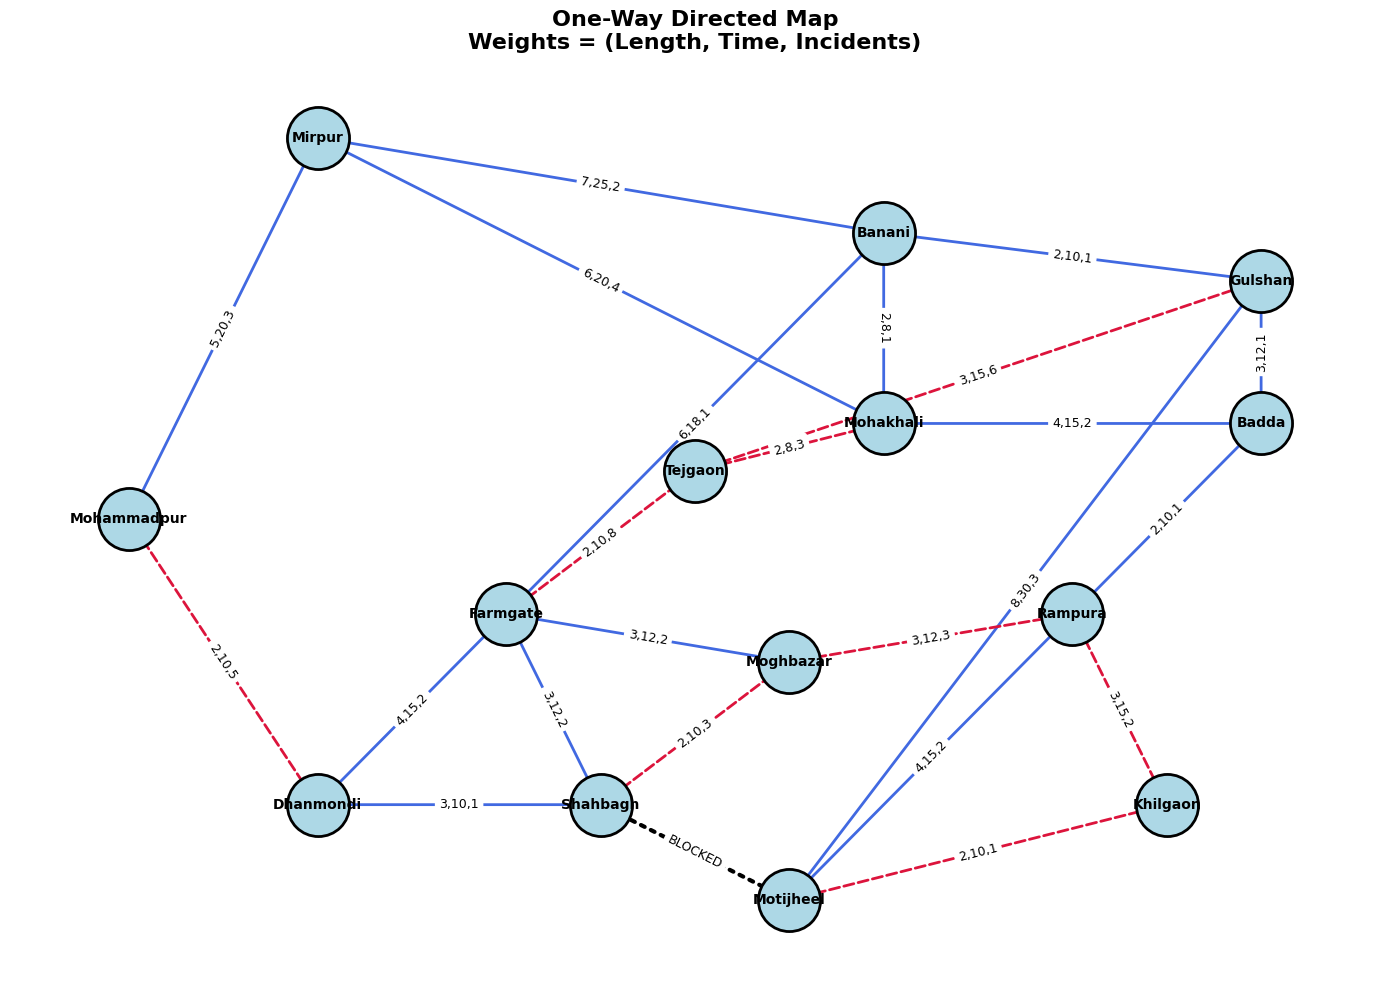

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. DEFINE THE NETWORK DATA ---
# (Node A, Node B, Length, Time, Incidents, Blocked, Type)
edges = [
    ('Dhanmondi', 'Farmgate', 4, 15, 2, False, 'Primary'),
    ('Dhanmondi', 'Shahbagh', 3, 10, 1, False, 'Primary'),
    ('Dhanmondi', 'Mohammadpur', 2, 10, 5, False, 'Alley'),
    ('Mohammadpur', 'Mirpur', 5, 20, 3, False, 'Primary'),
    ('Shahbagh', 'Farmgate', 3, 12, 2, False, 'Primary'),
    ('Shahbagh', 'Motijheel', 4, 20, 4, True, 'Primary'),   # BLOCKED
    ('Shahbagh', 'Moghbazar', 2, 10, 3, False, 'Alley'),
    ('Farmgate', 'Banani', 6, 18, 1, False, 'Primary'),
    ('Farmgate', 'Tejgaon', 2, 10, 8, False, 'Alley'),
    ('Farmgate', 'Moghbazar', 3, 12, 2, False, 'Primary'),
    ('Mirpur', 'Banani', 7, 25, 2, False, 'Primary'),
    ('Mirpur', 'Mohakhali', 6, 20, 4, False, 'Primary'),
    ('Tejgaon', 'Gulshan', 3, 15, 6, False, 'Alley'),
    ('Tejgaon', 'Mohakhali', 2, 8, 3, False, 'Alley'),
    ('Banani', 'Gulshan', 2, 10, 1, False, 'Primary'),
    ('Banani', 'Mohakhali', 2, 8, 1, False, 'Primary'),
    ('Motijheel', 'Gulshan', 8, 30, 3, False, 'Primary'),
    ('Motijheel', 'Rampura', 4, 15, 2, False, 'Primary'),
    ('Moghbazar', 'Rampura', 3, 12, 3, False, 'Alley'),
    ('Mohakhali', 'Badda', 4, 15, 2, False, 'Primary'),
    ('Rampura', 'Badda', 2, 10, 1, False, 'Primary'),
    ('Badda', 'Gulshan', 3, 12, 1, False, 'Primary'),
    ('Motijheel', 'Khilgaon', 2, 10, 1, False, 'Alley'),
    ('Khilgaon', 'Rampura', 3, 15, 2, False, 'Alley')
]

# --- 2. BUILD STRICTLY ONE-WAY DIRECTED GRAPH ---
G = nx.DiGraph()

for u, v, length, time, incidents, blocked, road_type in edges:
    # Add the blocked attribute so the graph remembers which roads are closed
    label_string = f"{length},{time},{incidents}"
    G.add_edge(u, v, weight=label_string, road_type=road_type, blocked=blocked)

# --- 3. DEFINE GEOGRAPHIC POSITIONS ---
pos = {
    'Mirpur': (2, 8),
    'Banani': (5, 7),
    'Gulshan': (7, 6.5),
    'Mohakhali': (5, 5),
    'Badda': (7, 5),
    'Tejgaon': (4, 4.5),
    'Mohammadpur': (1, 4),
    'Farmgate': (3, 3),
    'Moghbazar': (4.5, 2.5),
    'Rampura': (6, 3),
    'Dhanmondi': (2, 1),
    'Shahbagh': (3.5, 1),
    'Motijheel': (4.5, 0),
    'Khilgaon': (6.5, 1)
}

# --- 4. VISUAL STYLING ---
plt.figure(figsize=(14, 10))
plt.title("One-Way Directed Map\nWeights = (Length, Time, Incidents)", fontsize=16, fontweight='bold')

# Separate edges for coloring (Filter out blocked roads from normal drawing)
blocked_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('blocked', False)]
primary_edges = [(u, v) for u, v, d in G.edges(data=True) if d['road_type'] == 'Primary' and not d.get('blocked', False)]
alley_edges = [(u, v) for u, v, d in G.edges(data=True) if d['road_type'] == 'Alley' and not d.get('blocked', False)]

# Draw Nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', edgecolors='black', linewidths=2)

# Draw Node Labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_family='sans-serif')

# Draw Primary Roads (Solid Blue)
nx.draw_networkx_edges(G, pos, edgelist=primary_edges, width=2.0, edge_color='royalblue',
                       arrowsize=20, arrowstyle='-|>')

# Draw Alley Roads (Dashed Red)
nx.draw_networkx_edges(G, pos, edgelist=alley_edges, width=2.0, edge_color='crimson', style='dashed',
                       arrowsize=20, arrowstyle='-|>')

# Draw Blocked Roads (Thick Dotted Black)
nx.draw_networkx_edges(G, pos, edgelist=blocked_edges, width=3.0, edge_color='black', style='dotted',
                       arrowsize=20, arrowstyle='-|>')

# Draw Edge Labels (Overwrite weight label with "BLOCKED" if the road is closed)
edge_labels = {}
for u, v, d in G.edges(data=True):
    if d.get('blocked', False):
        edge_labels[(u, v)] = "BLOCKED"
    else:
        edge_labels[(u, v)] = d["weight"]

# label_pos=0.5 places the text exactly in the middle of the straight line
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='black', label_pos=0.5)

# --- 5. RENDER THE PLOT ---
plt.axis('off')
plt.tight_layout()
plt.show()